# Exploratory Data Analysis (EDA)

We load the cleaned dataset produced by `01_Data_Ingestion_Cleaning` and explore its structure, distributions, text characteristics and potential quality issues before moving to feature engineering and modeling.

In [17]:
import sys
sys.path.insert(0, "src")

# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from mean_squared_terrors.eda import top_tfidf_terms, top_tfidf_bigrams, price_bucket

# Global plot style — applies to every figure in this notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "sans-serif" 

In [18]:
# Loading the cleaned datasets produced by 01_Data_Ingestion_Cleaning
df   = pd.read_csv("data/reviews_cleaned.csv")
prod = pd.read_csv("data/products_cleaned.csv")
rev  = pd.read_csv("data/reviews_topN.csv")

print(f"Reviews (full):     {len(df):,}")
print(f"Products:           {len(prod):,}")
print(f"Reviews (top-N):    {len(rev):,}")
df.head()

Reviews (full):     319,018
Products:           7,647
Reviews (top-N):    57,192


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_title,brand,description_clean,features_clean,form_text,details_rest,price,store,product_avg_rating,product_rating_count
0,4,12 mg is 12 on the periodic table people! Mg f...,This review is more to clarify someone else's ...,NaN,B07TDSJZMR,B07TDSJZMR,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-06 00:49:35.902,3,True,High Potency Magnesium Citrate Capsules 1000mg...,Life Nutrition,NaN,NaN,NaN,Flavor: Unflavored. Product Benefits: Nutritional,NaN,Life Nutrition,4.577778,45
1,5,Fantastic,I have been suffering a couple months with hee...,NaN,B07KJVGNN5,B07KJVGNN5,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2019-07-24 11:13:58.905,0,True,"Dr. Foot's Gel Heel Protectors, Plantar Fascii...",Dr.Foot,NaN,NaN,NaN,NaN,NaN,Dr.Foot,3.916667,24
2,4,It holds the water and makes bubbles. That's w...,It's cheap and it does what I wanted. The mass...,NaN,B007HY7GC2,B092RP73CX,AEZGPLOYTSAPR3DHZKKXEFPAXUAA,2022-09-04 02:29:02.725,7,True,"Homedics Bubble Bliss Deluxe-Foot Spa, Heat Ma...",Homedics,NaN,Fizz your feet Active bubble massage soothes a...,Material: Plastic,Power Source: Corded Electric,NaN,Homedics,3.436207,580
3,1,Not for me,Didn't do a thing for me. Not saying they don'...,NaN,B08KYJLF5T,B08KYJLF5T,AEQAYV7RXZEBXMQIQPL6KCT2CFWQ,2022-01-20 23:53:07.262,0,True,Brain Supplement 1053mg - Premium Nootropic Br...,Nature's Nutrition,NaN,NaN,Item Form: Capsule. Dosage Form: Capsule,NaN,NaN,Nature's Nutrition,3.937500,16
4,5,returned,it was a nice tray smaller than i expected but...,NaN,B01H0SVP9O,B01H0SVP9O,AHGAOIZVODNHYMNCBV4DECZH42UQ,2020-11-11 14:54:54.192,0,True,North American Walker Tray with Non-Slip Grip Mat,North American Health Wellness,Walker tray with grip mat. Turn any walker int...,"Turn any walker into a TV tray, easily transfe...",NaN,NaN,26.9,North American Health + Wellness,3.343811,509


## Corpus-Level Profiling

Basic shape, column types, missing values and sample size of the final merged dataset.

Note: reviews with empty or near-empty text (≈0.3% of `df`) are kept in `reviews_cleaned.csv` because their star rating still contributes to the per-product aggregations (`product_avg_rating`, `product_rating_count`). They are excluded here from the balanced selection, since the embedding and BART summarization steps downstream require non-empty review text.

In [19]:
# Corpus size and column overview
print(f"Total reviews:                  {len(df):,}")
print(f"Unique products (parent_asin):  {df['parent_asin'].nunique():,}")
print(f"Unique reviewers (user_id):     {df['user_id'].nunique():,}")
print(f"Columns: {list(df.columns)}\n")

# Temporal coverage
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"Period: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}\n")

# Adding text length columns for analysis
df["char_len"] = df["text"].fillna("").astype(str).str.len()
df["tok_len"]  = df["text"].fillna("").astype(str).str.split().str.len()

# Summary table — more readable than raw describe()
summary = df[["char_len", "tok_len"]].agg(["mean", "median", "std", "min", "max"]).round(1)
summary.index.name = "stat"
print(summary)

Total reviews:                  319,018
Unique products (parent_asin):  7,658
Unique reviewers (user_id):     311,062
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'product_title', 'brand', 'description_clean', 'features_clean', 'form_text', 'details_rest', 'price', 'store', 'product_avg_rating', 'product_rating_count']

Period: 2004-02-25 → 2023-09-11

        char_len  tok_len
stat                     
mean       166.5     31.6
median     101.0     19.0
std        224.6     42.6
min          0.0      0.0
max      16357.0   2772.0


## Review Text Length Distributions

How long reviews are in tokens, and how length varies by star rating.

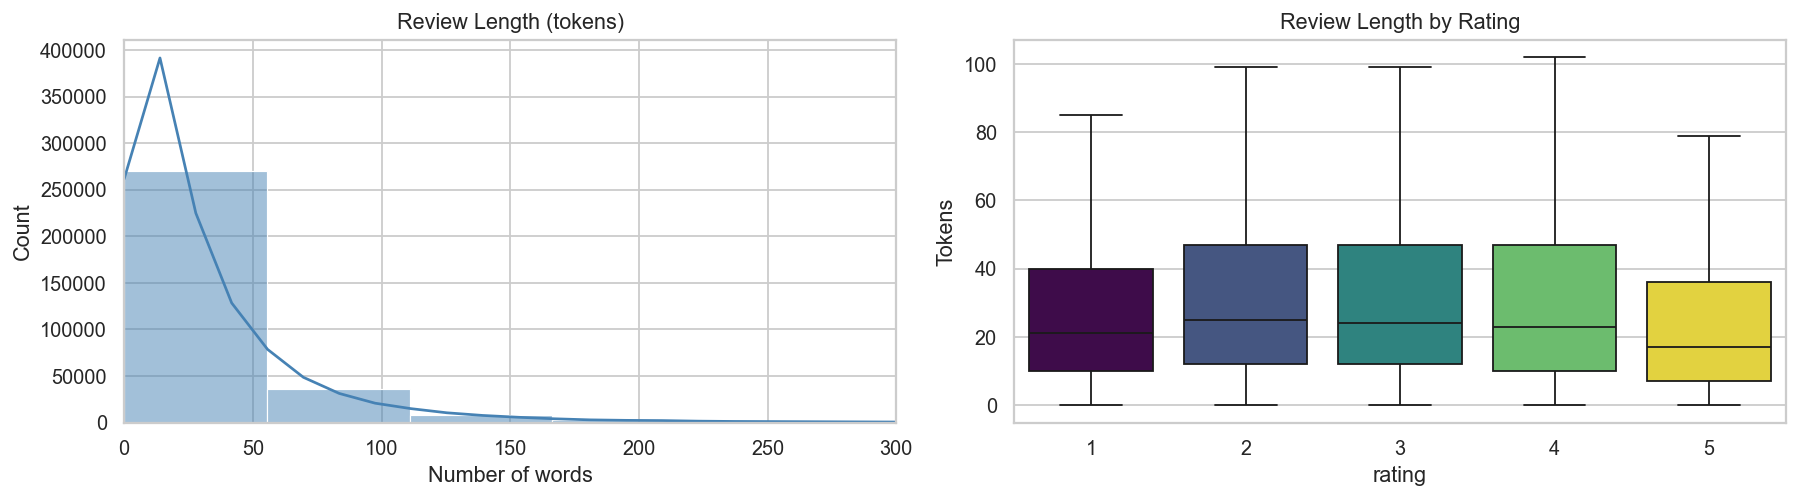

Token length per rating:
        mean tokens  median tokens  n reviews
rating                                       
1              32.1           21.0      44074
2              37.7           25.0      18878
3              37.4           24.0      23589
4              38.0           23.0      35641
5              29.1           17.0     196836


In [20]:
# Review length distributions (rating distribution is covered in the Rating Bias section)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Review length in tokens — capping at 300 to avoid outliers squashing the plot
sns.histplot(df["tok_len"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Review Length (tokens)")
axes[0].set_xlabel("Number of words")
axes[0].set_xlim(0, 300)

# Review length by rating — hiding outliers to keep boxes readable
sns.boxplot(x="rating", y="tok_len", data=df, ax=axes[1], palette="viridis",
            showfliers=False, hue="rating", legend=False)
axes[1].set_title("Review Length by Rating")
axes[1].set_ylabel("Tokens")

plt.tight_layout()
plt.show()

# Length statistics per rating
length_by_rating = df.groupby("rating")["tok_len"].agg(["mean", "median", "count"]).round(1)
length_by_rating.columns = ["mean tokens", "median tokens", "n reviews"]
print("Token length per rating:")
print(length_by_rating)

## Product-Level Overview

Field coverage across product metadata, token distribution in `product_text_base`, and reviews per product after balanced selection.

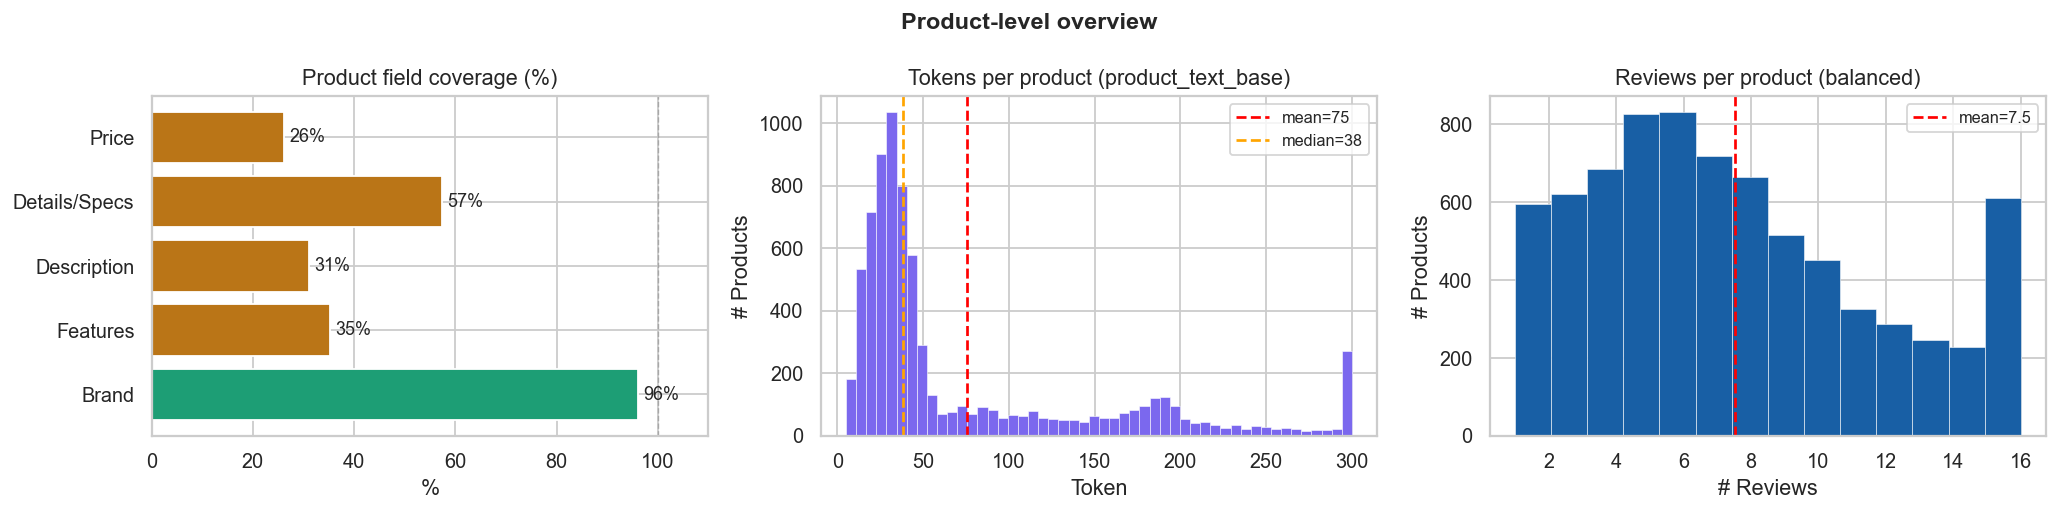

Products < 20 tokens (poor text):  13.7%
Products > 100 tokens (rich text): 25.3%


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Product-level overview", fontweight="bold", fontsize=13)

# 1 — Field coverage
fields = ["brand", "features_clean", "description_clean", "details_rest", "price"]
labels = ["Brand", "Features", "Description", "Details/Specs", "Price"]
pcts   = [prod[f].notna().mean() * 100 for f in fields]
colors = ["#1D9E75" if p > 60 else "#BA7517" if p > 25 else "#D85A30" for p in pcts]
bars = axes[0].barh(labels, pcts, color=colors, edgecolor="white")
axes[0].axvline(100, color="grey", ls="--", lw=0.8, alpha=0.5)
axes[0].set(title="Product field coverage (%)", xlabel="%", xlim=(0, 110))
for bar, pct in zip(bars, pcts):
    axes[0].text(pct + 1, bar.get_y() + bar.get_height() / 2,
                 f"{pct:.0f}%", va="center", fontsize=10)

# 2 — Token distribution in product_text_base
axes[1].hist(prod["text_tokens"].clip(upper=300), bins=50,
             color="#7B68EE", edgecolor="white", linewidth=0.3)
axes[1].axvline(prod["text_tokens"].mean(),   color="red",    ls="--", lw=1.5,
                label=f"mean={prod['text_tokens'].mean():.0f}")
axes[1].axvline(prod["text_tokens"].median(), color="orange", ls="--", lw=1.5,
                label=f"median={prod['text_tokens'].median():.0f}")
axes[1].set(title="Tokens per product (product_text_base)", xlabel="Token", ylabel="# Products")
axes[1].legend(fontsize=9)

# 3 — Reviews per product (balanced selection)
rpp = rev.groupby("parent_asin").size()
axes[2].hist(rpp.clip(upper=16), bins=14, color="#185FA5", edgecolor="white", linewidth=0.3)
axes[2].axvline(rpp.mean(), color="red", ls="--", lw=1.5, label=f"mean={rpp.mean():.1f}")
axes[2].set(title="Reviews per product (balanced)", xlabel="# Reviews", ylabel="# Products")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Products < 20 tokens (poor text):  {(prod['text_tokens'] < 20).mean():.1%}")
print(f"Products > 100 tokens (rich text): {(prod['text_tokens'] > 100).mean():.1%}")

## Rating Bias — Raw vs Balanced Selection

The raw dataset is heavily skewed toward 5-star reviews (~61%). The balanced selection strategy caps reviews per rating band, reducing 5-star bias to ~48%. The third chart compares 5-star percentage across pipeline versions.

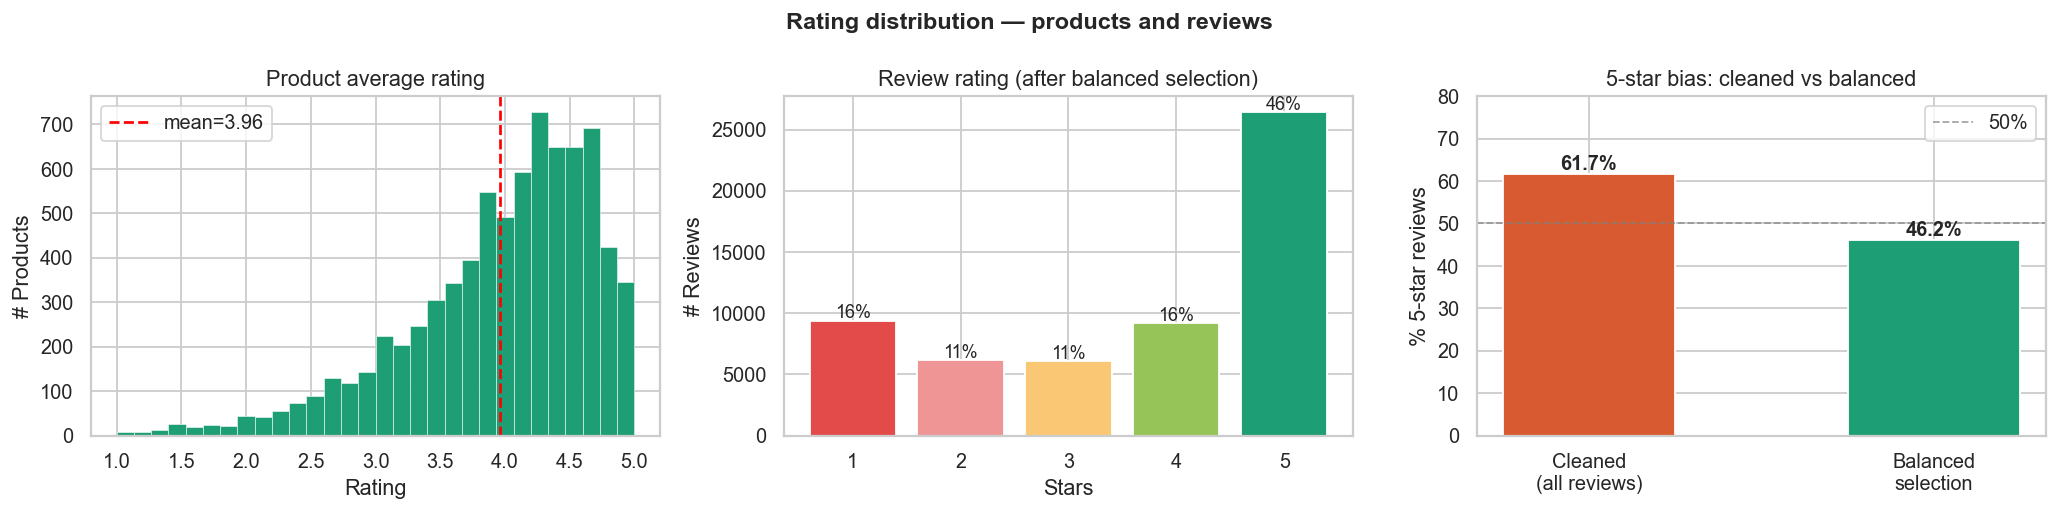

Review rating distribution (balanced):
  1 stars: 9,387 (16.4%)
  2 stars: 6,146 (10.7%)
  3 stars: 6,108 (10.7%)
  4 stars: 9,155 (16.0%)
  5 stars: 26,396 (46.2%)


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Rating distribution — products and reviews", fontweight="bold", fontsize=13)

# 1 — Product average rating
axes[0].hist(prod["product_avg_rating"].dropna(), bins=30,
             color="#1D9E75", edgecolor="white", linewidth=0.3)
axes[0].axvline(prod["product_avg_rating"].mean(), color="red", ls="--", lw=1.5,
                label=f"mean={prod['product_avg_rating'].mean():.2f}")
axes[0].set(title="Product average rating", xlabel="Rating", ylabel="# Products")
axes[0].legend()

# 2 — Review rating distribution (balanced selection)
r_counts = [rev[rev["rating"] == r].shape[0] for r in [1, 2, 3, 4, 5]]
r_colors = ["#E24B4A", "#F09595", "#FAC775", "#97C459", "#1D9E75"]
bars = axes[1].bar([1, 2, 3, 4, 5], r_counts, color=r_colors, edgecolor="white")
axes[1].set(title="Review rating (after balanced selection)", xlabel="Stars", ylabel="# Reviews")
total_r = sum(r_counts)
for bar, cnt in zip(bars, r_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f"{cnt / total_r:.0%}", ha="center", fontsize=10)

# 3 — 5-star bias comparison across versions
pct_5_raw      = (df["rating"] == 5).mean() * 100
pct_5_balanced = (rev["rating"] == 5).mean() * 100
versions  = ["Cleaned\n(all reviews)", "Balanced\nselection"]
pct_5star = [pct_5_raw, pct_5_balanced]
colors_v  = ["#D85A30", "#1D9E75"]
bars2 = axes[2].bar(versions, pct_5star, color=colors_v, edgecolor="white", width=0.5)
axes[2].axhline(50, color="grey", ls="--", lw=1, alpha=0.7, label="50%")
axes[2].set(title="5-star bias: cleaned vs balanced", ylabel="% 5-star reviews", ylim=(0, 80))
for bar, pct in zip(bars2, pct_5star):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{pct:.1f}%", ha="center", fontweight="bold", fontsize=11)
axes[2].legend()

plt.tight_layout()
plt.show()

print("Review rating distribution (balanced):")
for r in [1, 2, 3, 4, 5]:
    n = (rev["rating"] == r).sum()
    print(f"  {r} stars: {n:,} ({n / len(rev):.1%})")

## Text Quality — Token Stats & Helpful Votes

Review token distribution after the minimum 25-token filter, mean token contribution of each metadata component to `product_text_base` (TITLE/BRAND/FORM/FEATURES/DESCRIPTION/SPECS), and helpful-vote coverage across the balanced review set.

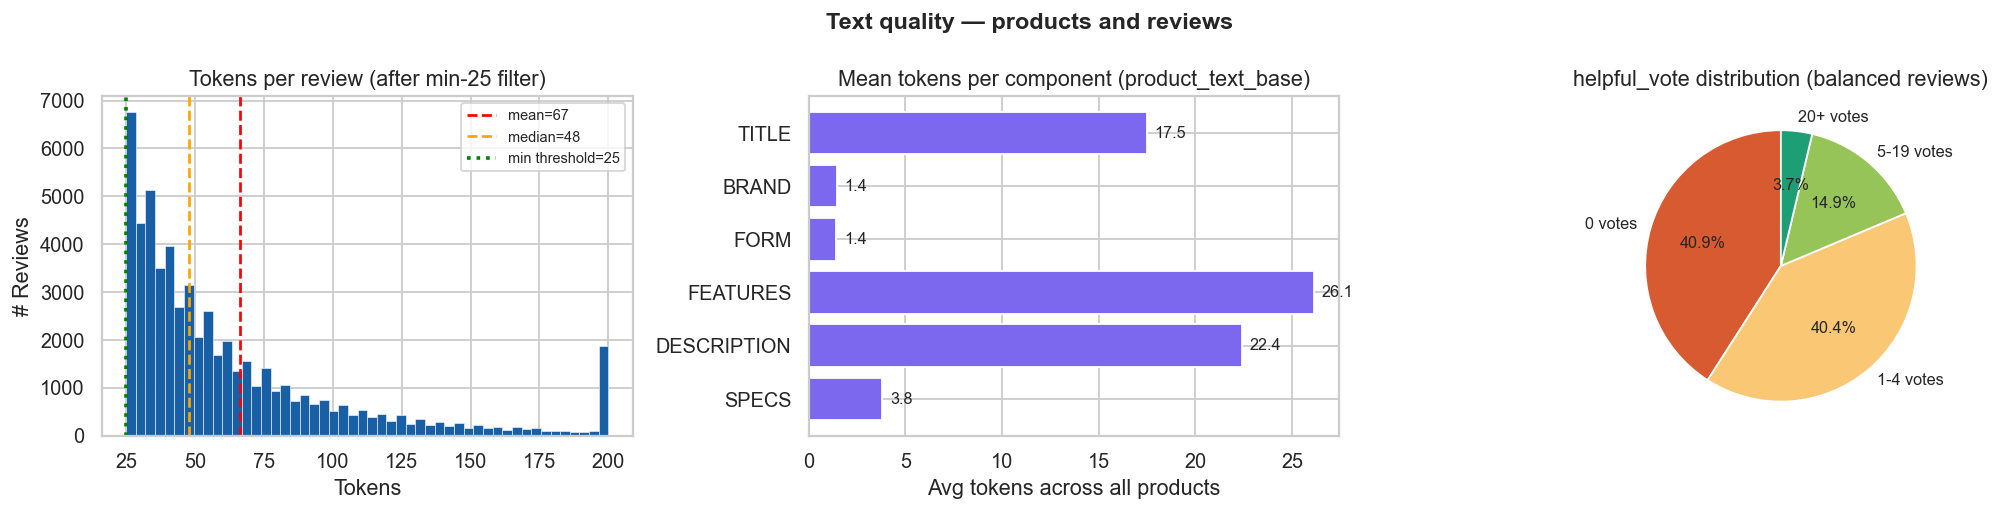

Mean review tokens:  67
Median review tokens: 48
P90 review tokens:   122
With helpful_vote > 0: 59.1%

Mean tokens per component (product_text_base):
  TITLE         17.5
  BRAND          1.4
  FORM           1.4
  FEATURES      26.1
  DESCRIPTION   22.4
  SPECS          3.8


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Text quality — products and reviews", fontweight="bold", fontsize=13)

# 1 — Review token distribution (balanced set)
axes[0].hist(rev["tok_len"].clip(upper=200), bins=50,
             color="#185FA5", edgecolor="white", linewidth=0.3)
axes[0].axvline(rev["tok_len"].mean(),   color="red",    ls="--", lw=1.5,
                label=f"mean={rev['tok_len'].mean():.0f}")
axes[0].axvline(rev["tok_len"].median(), color="orange", ls="--", lw=1.5,
                label=f"median={rev['tok_len'].median():.0f}")
axes[0].axvline(25, color="green", ls=":", lw=2, label="min threshold=25")
axes[0].set(title="Tokens per review (after min-25 filter)", xlabel="Tokens", ylabel="# Reviews")
axes[0].legend(fontsize=8)

# 2 — Composition of product_text_base by component (mean tokens, averaged across all products)
def _count_tokens(s):
    return 0 if pd.isna(s) else len(str(s).split())

components = {
    "TITLE":       prod["product_title"].apply(_count_tokens),
    "BRAND":       prod["brand"].apply(_count_tokens),
    "FORM":        prod["form_text"].apply(_count_tokens),
    "FEATURES":    prod["features_clean"].apply(_count_tokens),
    "DESCRIPTION": prod["description_clean"].apply(_count_tokens),
    "SPECS":       prod["details_rest"].apply(_count_tokens),
}
mean_per_component = {k: v.mean() for k, v in components.items()}
labels = list(mean_per_component.keys())
values = list(mean_per_component.values())

bars3 = axes[1].barh(labels, values, color="#7B68EE", edgecolor="white")
axes[1].invert_yaxis()  # TITLE on top, SPECS at bottom — matches build_product_text order
axes[1].set(title="Mean tokens per component (product_text_base)",
            xlabel="Avg tokens across all products")
for bar, v in zip(bars3, values):
    axes[1].text(v + 0.4, bar.get_y() + bar.get_height() / 2,
                 f"{v:.1f}", va="center", fontsize=9)

# 3 — Helpful vote distribution (pie chart)
hv = rev["helpful_vote"].fillna(0)
hv_buckets = ["0 votes", "1-4 votes", "5-19 votes", "20+ votes"]
hv_counts  = [
    (hv == 0).sum(),
    ((hv >= 1) & (hv < 5)).sum(),
    ((hv >= 5) & (hv < 20)).sum(),
    (hv >= 20).sum(),
]
hv_colors = ["#D85A30", "#FAC775", "#97C459", "#1D9E75"]
axes[2].pie(hv_counts, labels=hv_buckets, colors=hv_colors,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 9})
axes[2].set_title("helpful_vote distribution (balanced reviews)")

plt.tight_layout()
plt.show()

print(f"Mean review tokens:  {rev['tok_len'].mean():.0f}")
print(f"Median review tokens: {rev['tok_len'].median():.0f}")
print(f"P90 review tokens:   {rev['tok_len'].quantile(0.9):.0f}")
print(f"With helpful_vote > 0: {(hv > 0).mean():.1%}")
print()
print("Mean tokens per component (product_text_base):")
for k, v in mean_per_component.items():
    print(f"  {k:<12} {v:5.1f}")

## Top Words and N-grams

We extract the most frequent unigrams (single words) and bigrams (two-word phrases) from the balanced review set the model will actually see, to get a first sense of the vocabulary and recurring themes. English stopwords are removed, along with domain-specific terms (product, buy, amazon, etc.) that are too generic to carry meaningful signal — they were identified iteratively by inspecting preliminary outputs. The bars are sorted by frequency in descending order.

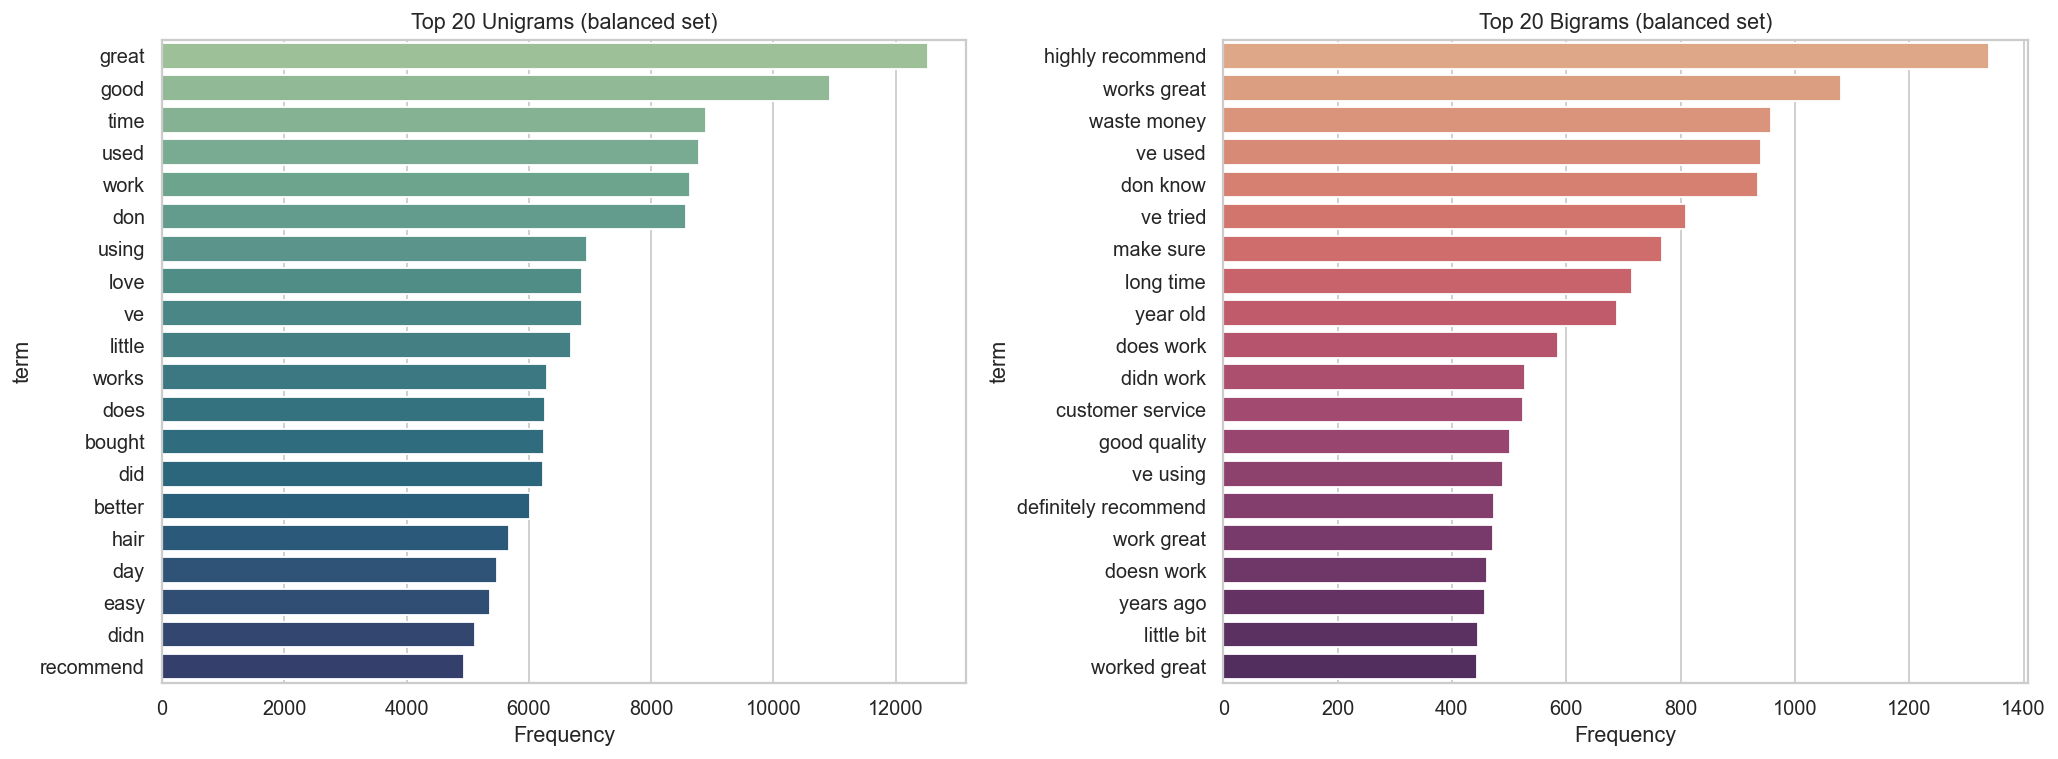

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# Using rev (balanced set) — these are the reviews the model will actually see
texts = rev["text"].fillna("").astype(str)

# Domain-specific stopwords to add on top of sklearn's English list
DOMAIN_STOPWORDS = [
    "product", "buy", "amazon", "just", "really", "get", "one",
    "use", "like", "also", "even", "would", "could", "still"
]
combined_stopwords = list(CountVectorizer(stop_words="english").get_stop_words()) + DOMAIN_STOPWORDS

# Top 20 unigrams (no stopwords)
vec_uni = CountVectorizer(stop_words=combined_stopwords, max_features=20)
X_uni = vec_uni.fit_transform(texts)
uni_freq = X_uni.sum(axis=0).A1
uni_terms = vec_uni.get_feature_names_out()

# Sort by frequency descending
order_uni = uni_freq.argsort()[::-1]
uni_terms, uni_freq = uni_terms[order_uni], uni_freq[order_uni]

# Top 20 bigrams (no stopwords)
vec_bi = CountVectorizer(ngram_range=(2, 2), stop_words=combined_stopwords, max_features=20)
X_bi = vec_bi.fit_transform(texts)
bi_freq = X_bi.sum(axis=0).A1
bi_terms = vec_bi.get_feature_names_out()

# Sort by frequency descending
order_bi = bi_freq.argsort()[::-1]
bi_terms, bi_freq = bi_terms[order_bi], bi_freq[order_bi]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_uni = pd.DataFrame({"term": uni_terms, "freq": uni_freq})
df_bi  = pd.DataFrame({"term": bi_terms,  "freq": bi_freq})

sns.barplot(x="freq", y="term", data=df_uni, ax=axes[0], palette="crest",
            hue="term", legend=False)
axes[0].set_title("Top 20 Unigrams (balanced set)")
axes[0].set_xlabel("Frequency")

sns.barplot(x="freq", y="term", data=df_bi, ax=axes[1], palette="flare",
            hue="term", legend=False)
axes[1].set_title("Top 20 Bigrams (balanced set)")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## TF-IDF Top Terms per Rating Class

We split reviews into **positive (4-5 stars)** and **negative (1-2 stars)** and extract the most distinctive terms for each group using TF-IDF.

3-star reviews are deliberately excluded, neutral reviews tend to mix positive and negative vocabulary without adding useful discriminative signal.

A single TF-IDF model is fitted on the combined corpus (positive + negative) so that weights are on the same scale and the two groups are directly comparable.

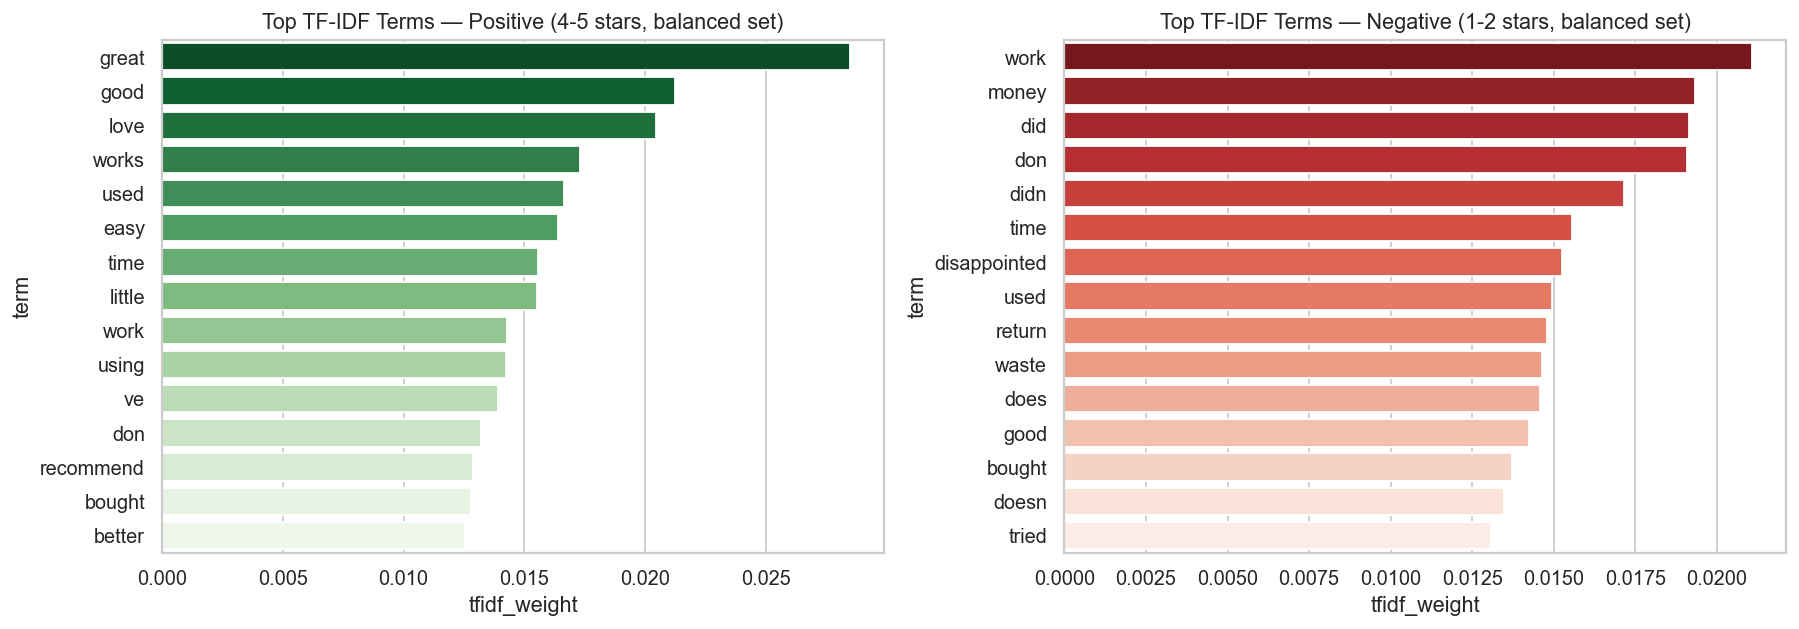

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Using rev (balanced set) — split into positive and negative groups
pos_texts = rev[rev["rating"] >= 4]["text"].fillna("").astype(str)
neg_texts = rev[rev["rating"] <= 2]["text"].fillna("").astype(str)
all_texts  = pd.concat([pos_texts, neg_texts])

# Fit a SINGLE TF-IDF on the full balanced corpus so weights are on the same scale
tfidf = TfidfVectorizer(stop_words=combined_stopwords, max_features=5000, sublinear_tf=True)
tfidf.fit(all_texts)

top_pos = top_tfidf_terms(tfidf, pos_texts)
top_neg = top_tfidf_terms(tfidf, neg_texts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x="tfidf_weight", y="term", data=top_pos, ax=axes[0], palette="Greens_r",
            hue="term", legend=False)
axes[0].set_title("Top TF-IDF Terms — Positive (4-5 stars, balanced set)")

sns.barplot(x="tfidf_weight", y="term", data=top_neg, ax=axes[1], palette="Reds_r",
            hue="term", legend=False)
axes[1].set_title("Top TF-IDF Terms — Negative (1-2 stars, balanced set)")

plt.tight_layout()
plt.show()

### Limitation: Negation Blindness

Some terms in the negative group don't make much sense at first glance: `good` and `work` show up in both positive and negative reviews. The reason is that bag-of-words has no notion of negation — `doesn't work` and `works great` both contribute the unigram *work* to the count.

Using bigrams should help, since `doesn't work` and `works great` become two distinct features.

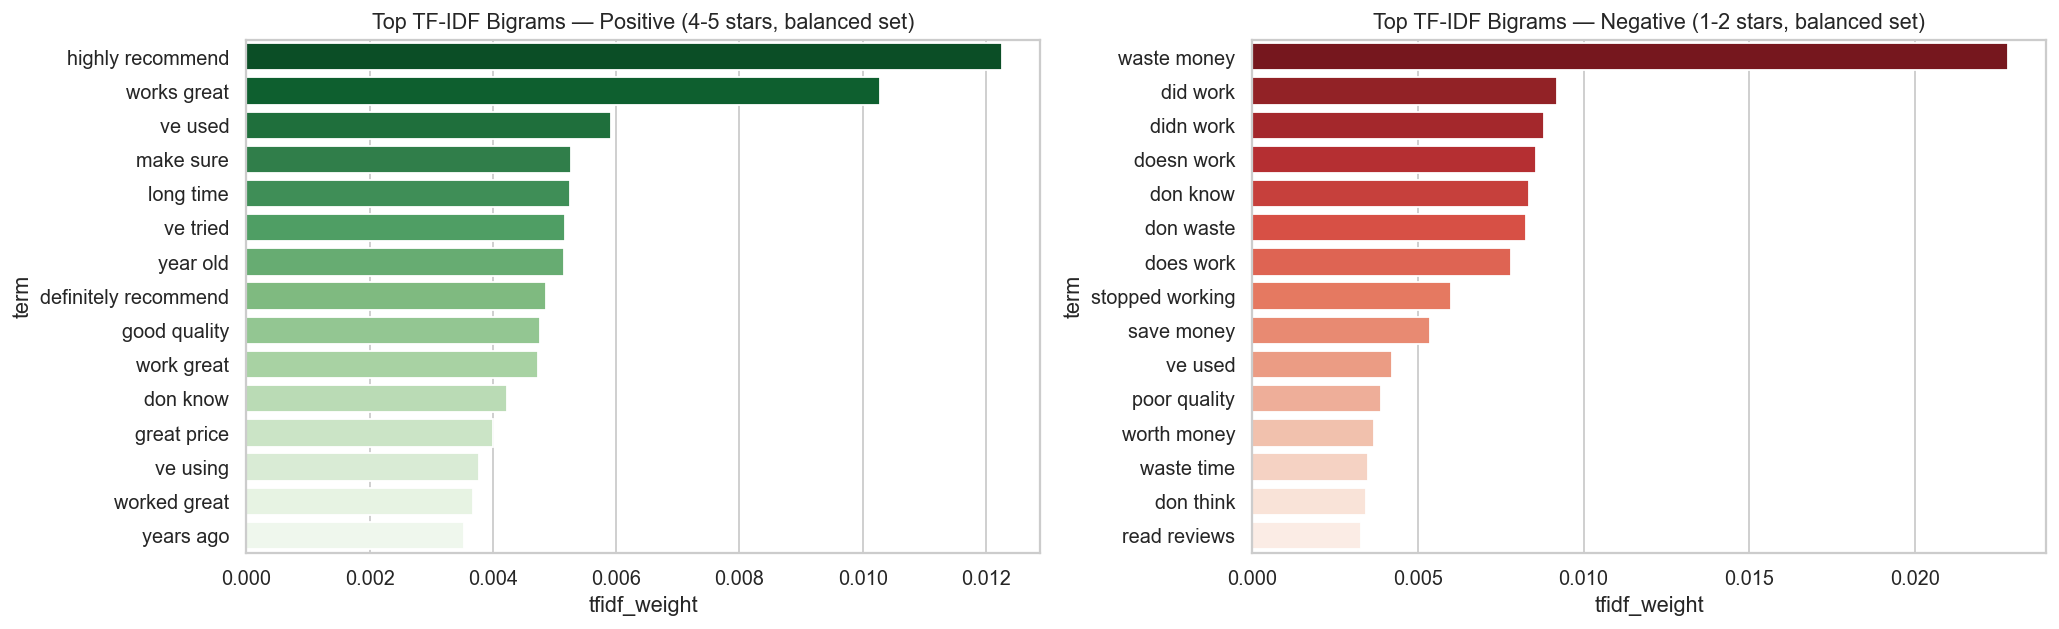

In [26]:
# TF-IDF with bigrams
tfidf_bi = TfidfVectorizer(
    stop_words=combined_stopwords,
    max_features=5000,
    sublinear_tf=True,
    ngram_range=(2, 2)   # bigrams only
)
tfidf_bi.fit(all_texts)

top_pos_bi = top_tfidf_bigrams(tfidf_bi, pos_texts)
top_neg_bi = top_tfidf_bigrams(tfidf_bi, neg_texts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x="tfidf_weight", y="term", data=top_pos_bi, ax=axes[0], palette="Greens_r",
            hue="term", legend=False)
axes[0].set_title("Top TF-IDF Bigrams — Positive (4-5 stars, balanced set)")

sns.barplot(x="tfidf_weight", y="term", data=top_neg_bi, ax=axes[1], palette="Reds_r",
            hue="term", legend=False)
axes[1].set_title("Top TF-IDF Bigrams — Negative (1-2 stars, balanced set)")

plt.tight_layout()
plt.show()

## Sentiment Polarity Check

Quick polarity scoring with TextBlob to compare automated sentiment against the user-given star rating.

Note: 2-star reviews show a surprisingly positive median polarity. This is likely because reviews like *"great product but stopped working after a week"* have enough positive language to pull the score up, even though the overall experience was negative.

Average polarity by star rating (balanced set):
rating
1   -0.004792
2    0.071040
3    0.119548
4    0.178547
5    0.253863
Name: polarity, dtype: float64

Sentiment-rating mismatch rate: 4.18%


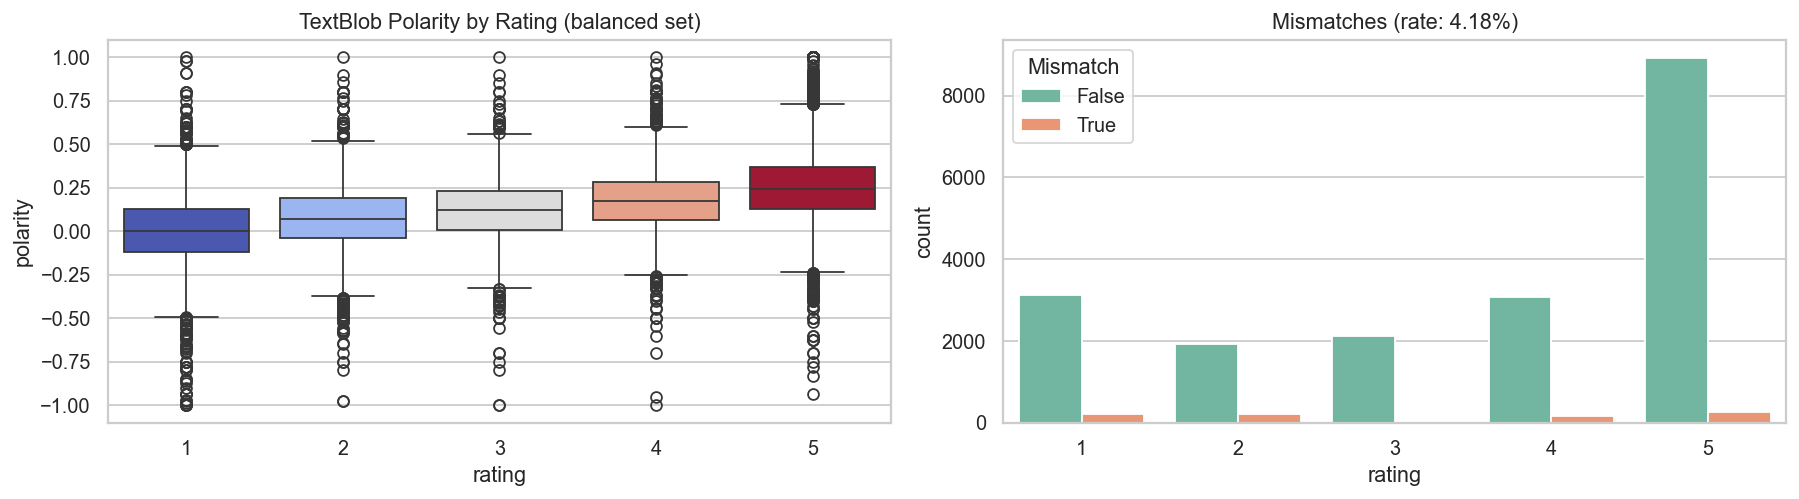

In [27]:
from textblob import TextBlob

# Computing polarity on the balanced set — these are the reviews the model will use
POLARITY_SAMPLE = min(20_000, len(rev))
df_pol = rev.sample(POLARITY_SAMPLE, random_state=42).copy()
df_pol["polarity"] = df_pol["text"].fillna("").astype(str).apply(lambda t: TextBlob(t).sentiment.polarity)

# Average polarity per star rating
pol_by_rating = df_pol.groupby("rating")["polarity"].mean()
print("Average polarity by star rating (balanced set):")
print(pol_by_rating)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x="rating", y="polarity", data=df_pol, ax=axes[0],
            palette="coolwarm", hue="rating", legend=False)
axes[0].set_title("TextBlob Polarity by Rating (balanced set)")

# Mismatch analysis: low rating but high polarity (and vice versa)
df_pol["mismatch"] = (
    ((df_pol["rating"] <= 2) & (df_pol["polarity"] > 0.3)) |
    ((df_pol["rating"] >= 4) & (df_pol["polarity"] < -0.1))
)
mismatch_rate = df_pol["mismatch"].mean()
print(f"\nSentiment-rating mismatch rate: {mismatch_rate:.2%}")

sns.countplot(x="rating", hue="mismatch", data=df_pol, ax=axes[1], palette="Set2")
axes[1].set_title(f"Mismatches (rate: {mismatch_rate:.2%})")
axes[1].legend(title="Mismatch")

plt.tight_layout()
plt.show()

## Price Distribution

Price data is available for only ~26% of products. This is a known limitation of the dataset — downstream steps handle it by making price filters soft (they only apply when the field is populated).

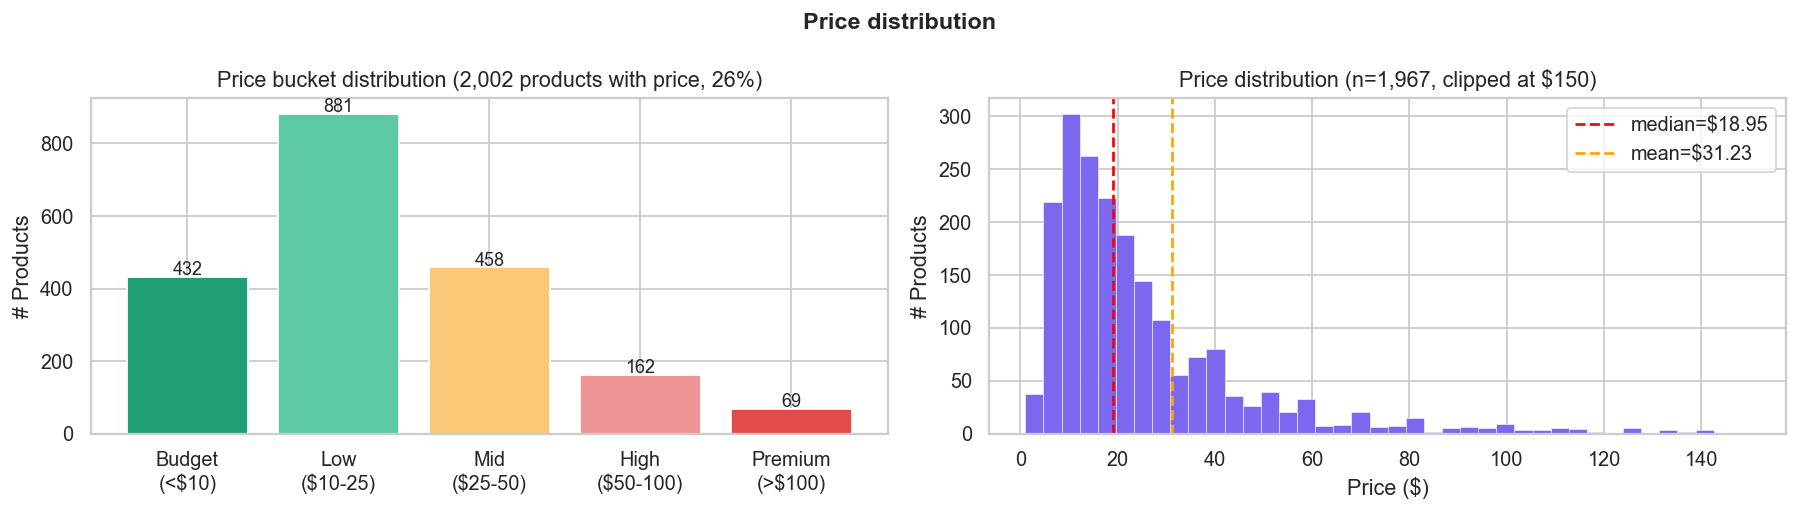

Products with price: 2,002 (26.2%)
Median price: $18.95
Mean price:   $31.23
Max price:    $1851.15


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Price distribution", fontweight="bold", fontsize=13)

# Create price buckets on the fly
prices = prod["price"].dropna()

prod_with_price = prod[prod["price"].notna()].copy()
prod_with_price["price_bucket"] = prod_with_price["price"].apply(price_bucket)

# 1 — Price bucket bar chart
bucket_order  = ["budget", "low", "mid", "high", "premium"]
bucket_labels = ["Budget\n(<$10)", "Low\n($10-25)", "Mid\n($25-50)", "High\n($50-100)", "Premium\n(>$100)"]
bucket_counts = [prod_with_price[prod_with_price["price_bucket"] == b].shape[0] for b in bucket_order]
b_colors      = ["#1D9E75", "#5DCAA5", "#FAC775", "#F09595", "#E24B4A"]
bars4 = axes[0].bar(bucket_labels, bucket_counts, color=b_colors, edgecolor="white")
axes[0].set(title=f"Price bucket distribution ({prices.notna().sum():,} products with price, {len(prices)/len(prod):.0%})",
            ylabel="# Products")
for bar, cnt in zip(bars4, bucket_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f"{cnt:,}", ha="center", fontsize=10)

# 2 — Price histogram (clipped at $150 to remove outliers)
prices_clip = prices[prices < 150]
axes[1].hist(prices_clip, bins=40, color="#7B68EE", edgecolor="white", linewidth=0.3)
axes[1].axvline(prices.median(), color="red",    ls="--", lw=1.5, label=f"median=${prices.median():.2f}")
axes[1].axvline(prices.mean(),   color="orange", ls="--", lw=1.5, label=f"mean=${prices.mean():.2f}")
axes[1].set(title=f"Price distribution (n={len(prices_clip):,}, clipped at $150)",
            xlabel="Price ($)", ylabel="# Products")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Products with price: {len(prices):,} ({len(prices)/len(prod):.1%})")
print(f"Median price: ${prices.median():.2f}")
print(f"Mean price:   ${prices.mean():.2f}")
print(f"Max price:    ${prices.max():.2f}")

## Final Summary — Key Numbers

In [29]:
print("=" * 60)
print("  DATASET SUMMARY")
print("=" * 60)
print()
print("OUTPUT (post-cleaning)")
print(f"  Products:                  {len(prod):,}")
print(f"  Reviews (full cleaned):    {len(df):,}")
print(f"  Reviews (balanced top-N):  {len(rev):,}")
print(f"  Reviews per product:       {len(rev)/len(prod):.1f} mean")
print(f"  Mean tokens per product:   {prod['text_tokens'].mean():.0f}")
print(f"  Mean tokens per review:    {rev['tok_len'].mean():.0f}")
print(f"  5-star bias (cleaned):         {(df['rating']==5).mean():.1%}")
print(f"  5-star bias (balanced):    {(rev['rating']==5).mean():.1%}")
print()
print("FIELD COVERAGE (products)")
for f, l in [("brand","Brand"), ("features_clean","Features"),
             ("description_clean","Description"), ("details_rest","Details"),
             ("price","Price")]:
    print(f"  {l:<20} {prod[f].notna().mean():.1%}")
print()
print("PRICE")
print(f"  Products with price:       {len(prices):,} ({len(prices)/len(prod):.1%})")
print(f"  Median price:              ${prices.median():.2f}")
print(f"  Mean price:                ${prices.mean():.2f}")
print()
print("TEXT QUALITY")
print(f"  Products < 20 tokens:      {(prod['text_tokens']<20).mean():.1%} (poor text)")
print(f"  Products > 100 tokens:     {(prod['text_tokens']>100).mean():.1%} (rich text)")
print(f"  Reviews with helpful > 0:  {(rev['helpful_vote'].fillna(0)>0).mean():.1%}")
print("=" * 60)

  DATASET SUMMARY

OUTPUT (post-cleaning)
  Products:                  7,647
  Reviews (full cleaned):    319,018
  Reviews (balanced top-N):  57,192
  Reviews per product:       7.5 mean
  Mean tokens per product:   75
  Mean tokens per review:    67
  5-star bias (cleaned):         61.7%
  5-star bias (balanced):    46.2%

FIELD COVERAGE (products)
  Brand                96.1%
  Features             35.3%
  Description          31.1%
  Details              57.3%
  Price                26.2%

PRICE
  Products with price:       2,002 (26.2%)
  Median price:              $18.95
  Mean price:                $31.23

TEXT QUALITY
  Products < 20 tokens:      13.7% (poor text)
  Products > 100 tokens:     25.3% (rich text)
  Reviews with helpful > 0:  59.1%
